# 03 — Feature Engineering

**Bối cảnh:** đề là **clustering** (unsupervised) — KHÔNG có target `y`. Ma trận đặc trưng `X` chính là input cho stage 4 phân cụm.

**Input:** `clean_data/clean_data_{train,test}.csv` (output của [02_Cleaning.ipynb](./02_Cleaning.ipynb), 17 cột).

**Output** trong `features/`:
- `X_{train,test}.npz` — sparse CSR (~32k chiều). Dùng cho cluster profiling (top TF-IDF token per centroid).
- `X_{train,test}_svd.npy` — dense sau TruncatedSVD (~100 chiều). Dùng cho K-Means/silhouette (sparse 32k chiều KHÔNG scale cho distance-based clustering).
- `transformers.joblib`, `meta.json`, `feature_names.txt`.

**Cấu trúc đặc trưng** (theo thứ tự cột trong X sparse):

| # | Nhóm | Cột nguồn | Transform | Chiều |
|---|---|---|---|---|
| 1 | numeric | `salary_min`, `salary_max`, `salary_mid`, `salary_missing`, `years_exp`, `year` | SimpleImputer(median) + StandardScaler | 6 |
| 2 | one_hot | `province`, `education_level`, `job_type`, `job_position` | OneHotEncoder(handle_unknown='ignore') | ~95 |
| 3 | industries | `industries_list` (split `\|`) | MultiLabelBinarizer | 51 |
| 4 | tfidf_job_title | `job_title` (text ngắn) | TfidfVectorizer max=5k, **ngram=(1,2)**, min_df=5 | ~5,000 |
| 5 | tfidf_job_description | `job_description` | TfidfVectorizer max=10k, ngram=(1,1) | ~10,000 |
| 6 | tfidf_requirements | `requirements` | TfidfVectorizer max=10k | ~9,000 |
| 7 | tfidf_benefits | `benefits` | TfidfVectorizer max=10k | ~8,000 |
| **Tổng (sparse)** | | | | **~32,000** |
| SVD | toàn bộ trên | TruncatedSVD(n_components=100, random_state=42) | dense float32 | **100** |

**Quy tắc:**
- Mọi transformer **fit trên train sample 150k** (full clean_data_train.csv ~1 GB sẽ OOM pandas), transform full train qua **chunked apply** (50k row/batch) + vstack sparse blocks → SVD transform once.
- KHÔNG có target — bỏ `y = log1p(expected_salary)` của bản regression.
- `salary` giờ là feature (3 cột numeric + 1 flag).
- TF-IDF dùng `strip_accents=None` — **giữ dấu tiếng Việt** (dấu mang nghĩa).
- TruncatedSVD `n_components=100` — chọn sau khi xem cumulative explained variance curve (Section 8).

In [1]:
from pathlib import Path
import json
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)

ROOT = Path.cwd().parent
CLEAN = ROOT / 'clean_data'
FEATURES = ROOT / 'features'
FEATURES.mkdir(exist_ok=True)
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
SAMPLE_SIZE = 150_000           # train sample để fit transformers (full ~1 GB → OOM pandas)
CHUNK_SIZE = 50_000             # batch size khi transform full train
SVD_N_COMPONENTS = 100          # số chiều dense sau TruncatedSVD

# Text dài (job_description, requirements, benefits) — unigram, vocab lớn
TFIDF_PARAMS_LONG = dict(
    max_features=10_000,
    min_df=10,
    max_df=0.95,
    sublinear_tf=True,
    ngram_range=(1, 1),
    lowercase=True,
    strip_accents=None,  # giữ dấu tiếng Việt
)

# Text ngắn (job_title) — bigram, vocab nhỏ
TFIDF_PARAMS_TITLE = dict(
    max_features=5_000,
    min_df=5,
    max_df=0.95,
    sublinear_tf=True,
    ngram_range=(1, 2),   # bigram bắt cụm: "kế toán trưởng", "senior engineer"
    lowercase=True,
    strip_accents=None,
)

TFIDF_COLS_PARAMS = [
    ('job_title', TFIDF_PARAMS_TITLE),
    ('job_description', TFIDF_PARAMS_LONG),
    ('requirements', TFIDF_PARAMS_LONG),
    ('benefits', TFIDF_PARAMS_LONG),
]
TEXT_COLS = [col for col, _ in TFIDF_COLS_PARAMS]

CAT_COLS = ['province', 'education_level', 'job_type', 'job_position']
NUM_COLS = ['salary_min', 'salary_max', 'salary_mid', 'salary_missing', 'years_exp', 'year']

print(f"Output dir: {FEATURES}")
print(f"SVD: {SVD_N_COMPONENTS} components")

Output dir: D:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\features
SVD: 100 components


## 1. Đọc clean data — sample 150k train + full test

- **Train sample 150k**: FIT toàn bộ transformer (imputer, scaler, OHE, MLB, TF-IDF, SVD).
- **Test full** (60,606 dòng / 115 MB): load đầy đủ.
- **Full train** (545k dòng / 1 GB): sẽ được TRANSFORM chunked ở Section 9 (50k/batch → vstack sparse).

In [2]:
def count_rows(path):
    with open(path, encoding='utf-8-sig') as f:
        return sum(1 for _ in f) - 1


def clean_df(df):
    """Post-load fix: fillna đúng theo loại cột + ép `salary_missing` về int8."""
    for col in TEXT_COLS + ['industries_list']:
        if col in df.columns:
            df[col] = df[col].fillna('').astype(str)
    for col in CAT_COLS:
        if col in df.columns:
            df[col] = df[col].fillna('unknown').astype(str)
    if 'salary_missing' in df.columns:
        df['salary_missing'] = df['salary_missing'].astype(bool).astype(np.int8)
    return df


N_TRAIN_FULL = count_rows(CLEAN / 'clean_data_train.csv')
N_TEST_FULL = count_rows(CLEAN / 'clean_data_test.csv')

rng_skip = np.random.RandomState(RANDOM_STATE)
n_skip = max(0, N_TRAIN_FULL - SAMPLE_SIZE)
skip_idx = set(rng_skip.choice(np.arange(1, N_TRAIN_FULL + 1), size=n_skip, replace=False).tolist())

train = clean_df(pd.read_csv(CLEAN / 'clean_data_train.csv',
                             skiprows=lambda i: i > 0 and i in skip_idx))
test = clean_df(pd.read_csv(CLEAN / 'clean_data_test.csv'))

print(f"Full dataset: train = {N_TRAIN_FULL:,} | test = {N_TEST_FULL:,}")
print(f"Sample dùng fit transformer: train = {len(train):,} | test = {len(test):,}")
print(f"\nNaN còn sót (train sample):")
miss = train.isna().sum()
print(miss[miss > 0].to_string() or '  (không cột nào NaN)')

Full dataset: train = 545,480 | test = 60,606
Sample dùng fit transformer: train = 150,000 | test = 60,606

NaN còn sót (train sample):
salary_min      8166
salary_max      8166
salary_mid      8166
years_exp       5713
company_name      24


## 2. Phân phối các feature `salary_*` — sẽ là numeric feature

Khác với bản regression (1 cột target `expected_salary`), bản clustering dùng **3 numeric feature** từ salary (`salary_min`, `salary_max`, `salary_mid`) + flag `salary_missing`. Phần này khảo sát phân phối để biết stage 4 (clustering) sẽ phải xử lý "scale" như thế nào.

In [3]:
salary_train = train[['salary_min', 'salary_max', 'salary_mid']].dropna()
print(f"Salary parsed (train sample): {len(salary_train):,}/{len(train):,} "
      f"({len(salary_train)/len(train)*100:.2f}%)")
print(f"\nThống kê 3 feature salary (triệu VNĐ):")
print(salary_train.describe().round(2).to_string())

print(f"\nsalary_missing flag (binary): {train['salary_missing'].sum():,} dòng "
      f"({train['salary_missing'].mean()*100:.2f}%)")

Salary parsed (train sample): 141,834/150,000 (94.56%)

Thống kê 3 feature salary (triệu VNĐ):
       salary_min  salary_max  salary_mid
count   141834.00   141834.00   141834.00
mean         9.83       16.84       13.33
std          4.70       10.40        6.84
min          0.00        0.00        0.15
25%          7.00       10.00        9.00
50%          9.00       15.00       12.00
75%         11.00       20.00       15.00
max         99.00      188.00      100.00

salary_missing flag (binary): 8,166 dòng (5.44%)


### Trực quan — phân phối 3 salary feature

`salary_min` và `salary_max` thường tạo dải lương; `salary_mid` là điểm giữa (sẽ dùng làm tín hiệu chính cho cluster centroid). Cả 3 đều lệch phải mạnh — sau StandardScaler vẫn còn skew nhưng K-Means không cần normal distribution, chỉ cần scale đồng nhất.

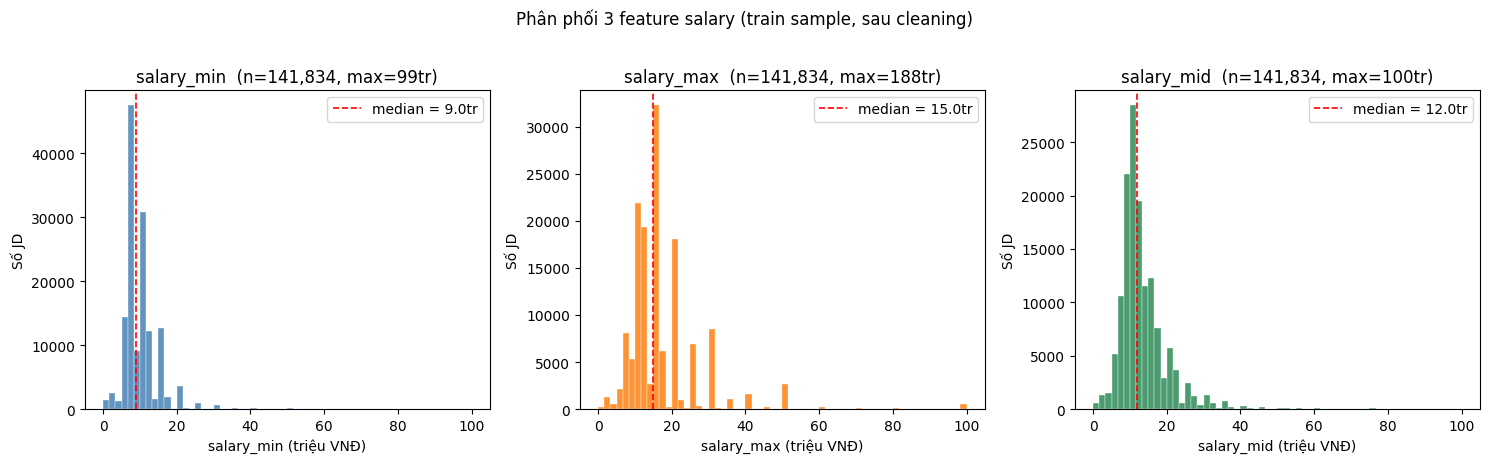

Đã lưu: D:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\figures\fe_salary_distributions.png


In [4]:
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

palette = ['steelblue', 'tab:orange', 'seagreen']
for ax, col, color in zip(axes, ['salary_min', 'salary_max', 'salary_mid'], palette):
    data = train[col].dropna()
    ax.hist(data, bins=60, range=(0, 100), color=color, alpha=0.85,
            edgecolor='white', linewidth=0.3)
    ax.axvline(data.median(), color='red', linestyle='--', lw=1.2,
               label=f'median = {data.median():.1f}tr')
    ax.set_xlabel(f'{col} (triệu VNĐ)')
    ax.set_ylabel('Số JD')
    ax.set_title(f'{col}  (n={len(data):,}, max={data.max():.0f}tr)')
    ax.legend()

plt.suptitle('Phân phối 3 feature salary (train sample, sau cleaning)', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fe_salary_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIG_DIR / 'fe_salary_distributions.png'}")

## 3. Numeric — 6 cột

Cột: `salary_min`, `salary_max`, `salary_mid`, `salary_missing` (binary 0/1), `years_exp`, `year`.

- **Impute median** fit trên train sample → áp full. Median của `salary_*` chỉ tính trên dòng parsed (NaN không tham gia).
- **StandardScaler** — center và scale tất cả 6 cột. K-Means dùng distance Euclidean nên scale là BẮT BUỘC (nếu không scale, `year`=2024 sẽ áp đảo `salary_mid`=12 trong distance).
- Khối numeric trở thành dense 6 cột — sẽ ép sang sparse để hstack với phần text TF-IDF.

In [5]:
num_imputer = SimpleImputer(strategy='median')
X_num_train = num_imputer.fit_transform(train[NUM_COLS])
print(f"Median (fit train sample):")
for col, med in zip(NUM_COLS, num_imputer.statistics_):
    print(f"  {col:18s}: {med}")

num_scaler = StandardScaler()
X_num_train_scaled = num_scaler.fit_transform(X_num_train).astype(np.float32)

print(f"\nNumeric stats (train sample, sau scale):")
for i, col in enumerate(NUM_COLS):
    arr = X_num_train_scaled[:, i]
    print(f"  {col:18s}: mean={arr.mean():+.3f}, std={arr.std():.3f}, "
          f"min={arr.min():+.3f}, max={arr.max():+.3f}")

Median (fit train sample):
  salary_min        : 9.0
  salary_max        : 15.0
  salary_mid        : 12.0
  salary_missing    : 0.0
  years_exp         : 3.0
  year              : 2024.0

Numeric stats (train sample, sau scale):
  salary_min        : mean=-0.000, std=1.000, min=-2.141, max=+19.523
  salary_max        : mean=+0.000, std=1.000, min=-1.653, max=+16.917
  salary_mid        : mean=-0.000, std=1.000, min=-1.968, max=+13.019
  salary_missing    : mean=-0.000, std=1.000, min=-0.240, max=+4.168
  years_exp         : mean=-0.000, std=1.000, min=-1.494, max=+11.953
  year              : mean=+0.000, std=1.000, min=-1.505, max=+1.771


### Trực quan — phân phối 6 numeric feature sau StandardScaler

Sau scale, mọi cột có mean ≈ 0, std ≈ 1. Đây là yêu cầu tối thiểu cho K-Means dựa trên Euclidean distance — không scale thì `year` (giá trị ~2024) sẽ áp đảo các feature khác.

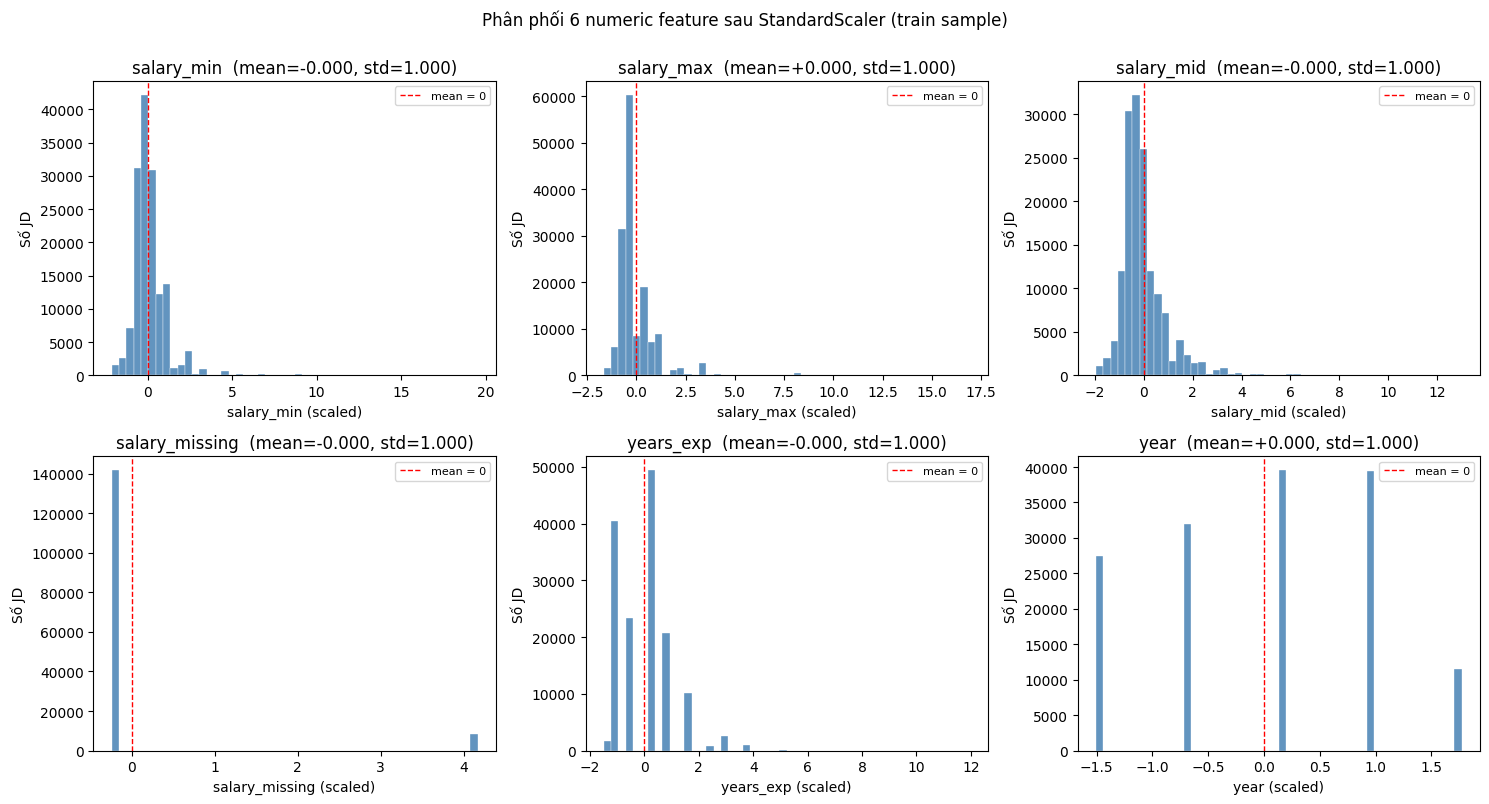

Đã lưu: D:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\figures\fe_numeric_scaled.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes_flat = axes.flat

for ax, col, idx in zip(axes_flat, NUM_COLS, range(len(NUM_COLS))):
    arr = X_num_train_scaled[:, idx]
    ax.hist(arr, bins=50, color='steelblue', alpha=0.85, edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='red', linestyle='--', lw=1, label='mean = 0')
    ax.set_xlabel(f'{col} (scaled)')
    ax.set_ylabel('Số JD')
    ax.set_title(f'{col}  (mean={arr.mean():+.3f}, std={arr.std():.3f})')
    ax.legend(fontsize=8)

plt.suptitle('Phân phối 6 numeric feature sau StandardScaler (train sample)', y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fe_numeric_scaled.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIG_DIR / 'fe_numeric_scaled.png'}")

## 4. Categorical → One-Hot

`handle_unknown='ignore'` để giá trị lạ trong test (vd. province không có ở train) thì cột tương ứng = 0 chứ không raise.

In [7]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True, dtype=np.float32)
X_cat_train = ohe.fit_transform(train[CAT_COLS])

print(f"X_cat_train: {X_cat_train.shape}")
print(f"\nSố category mỗi cột (fit trên train sample):")
for col, cats in zip(CAT_COLS, ohe.categories_):
    print(f"  {col:18s}: {len(cats):>3}")

X_cat_train: (150000, 145)

Số category mỗi cột (fit trên train sample):
  province          :  64
  education_level   :  10
  job_type          :  16
  job_position      :  55


## 5. Multi-label `industries_list`

Stage 2 đã chốt top-50 ngành base + `'Other'` → 51 lớp. Split `|` và đưa vào `MultiLabelBinarizer`.

Vì `industries_list` không bao giờ rỗng (stage 2 đã set fallback `'Other'`), không cần xử lý empty list.

In [8]:
def to_industry_list(s):
    return [x for x in s.split('|') if x]


train_inds = train['industries_list'].map(to_industry_list).tolist()

mlb = MultiLabelBinarizer(sparse_output=True)
X_ind_train = mlb.fit_transform(train_inds).astype(np.float32)

print(f"X_ind_train: {X_ind_train.shape}")
print(f"Số ngành: {len(mlb.classes_)}")
print(f"5 ngành đầu (alphabetical): {list(mlb.classes_[:5])}")

X_ind_train: (150000, 51)
Số ngành: 51
5 ngành đầu (alphabetical): ['Biên phiên dịch', 'Bán hàng', 'Bán hàng - Kinh doanh', 'Bán sỉ - Bán lẻ - Quản lý cửa hàng', 'Bất động sản']


## 6. TF-IDF cho 4 cột text — fit từng cột riêng với params khác nhau

Theo chốt ở [CLAUDE.md §5](../CLAUDE.md): vectorize **riêng từng cột** rồi `hstack` (không concat trước rồi vectorize 1 lần). Lý do: giữ phân biệt giữa "kinh nghiệm Python" trong `requirements` vs `benefits`.

**Params 2 loại:**
- `job_title` (text ngắn 5-20 từ): max_features=5k, **bigram (1,2)**, min_df=5 → bắt cụm "kế toán trưởng", "senior engineer"
- `job_description`, `requirements`, `benefits` (text dài): max_features=10k, unigram, min_df=10

Bước này tốn ~3-5 phút trên 459k docs × 4 cột.

In [9]:
tfidf_models = {}
text_train_blocks = []

for col, params in TFIDF_COLS_PARAMS:
    print(f"\n--- {col}  (ngram={params['ngram_range']}, max_features={params['max_features']:,}) ---")
    vec = TfidfVectorizer(**params)
    Xtr = vec.fit_transform(train[col]).astype(np.float32)
    tfidf_models[col] = vec
    text_train_blocks.append(Xtr)
    nnz_per_row = Xtr.getnnz(axis=1)
    print(f"  vocab kept    : {len(vec.vocabulary_):,}")
    print(f"  X_train shape : {Xtr.shape}")
    print(f"  nnz/row train : median={int(np.median(nnz_per_row))}, mean={nnz_per_row.mean():.1f}, max={nnz_per_row.max()}")


--- job_title  (ngram=(1, 2), max_features=5,000) ---


  vocab kept    : 5,000
  X_train shape : (150000, 5000)
  nnz/row train : median=11, mean=12.2, max=79

--- job_description  (ngram=(1, 1), max_features=10,000) ---


  vocab kept    : 9,748
  X_train shape : (150000, 9748)
  nnz/row train : median=70, mean=78.6, max=900

--- requirements  (ngram=(1, 1), max_features=10,000) ---


  vocab kept    : 6,047
  X_train shape : (150000, 6047)
  nnz/row train : median=48, mean=50.5, max=396

--- benefits  (ngram=(1, 1), max_features=10,000) ---


  vocab kept    : 4,902
  X_train shape : (150000, 4902)
  nnz/row train : median=54, mean=59.1, max=396


### Trực quan — top 15 token TF-IDF mỗi cột text

Token có **mean TF-IDF cao nhất** trên train — cho biết mỗi cột text nhấn vào khái niệm gì. `job_title` thường là bigram chức danh ("nhân viên", "kế toán"…), text dài thì là từ ngữ đặc trưng JD ("yêu cầu", "kinh nghiệm"…).

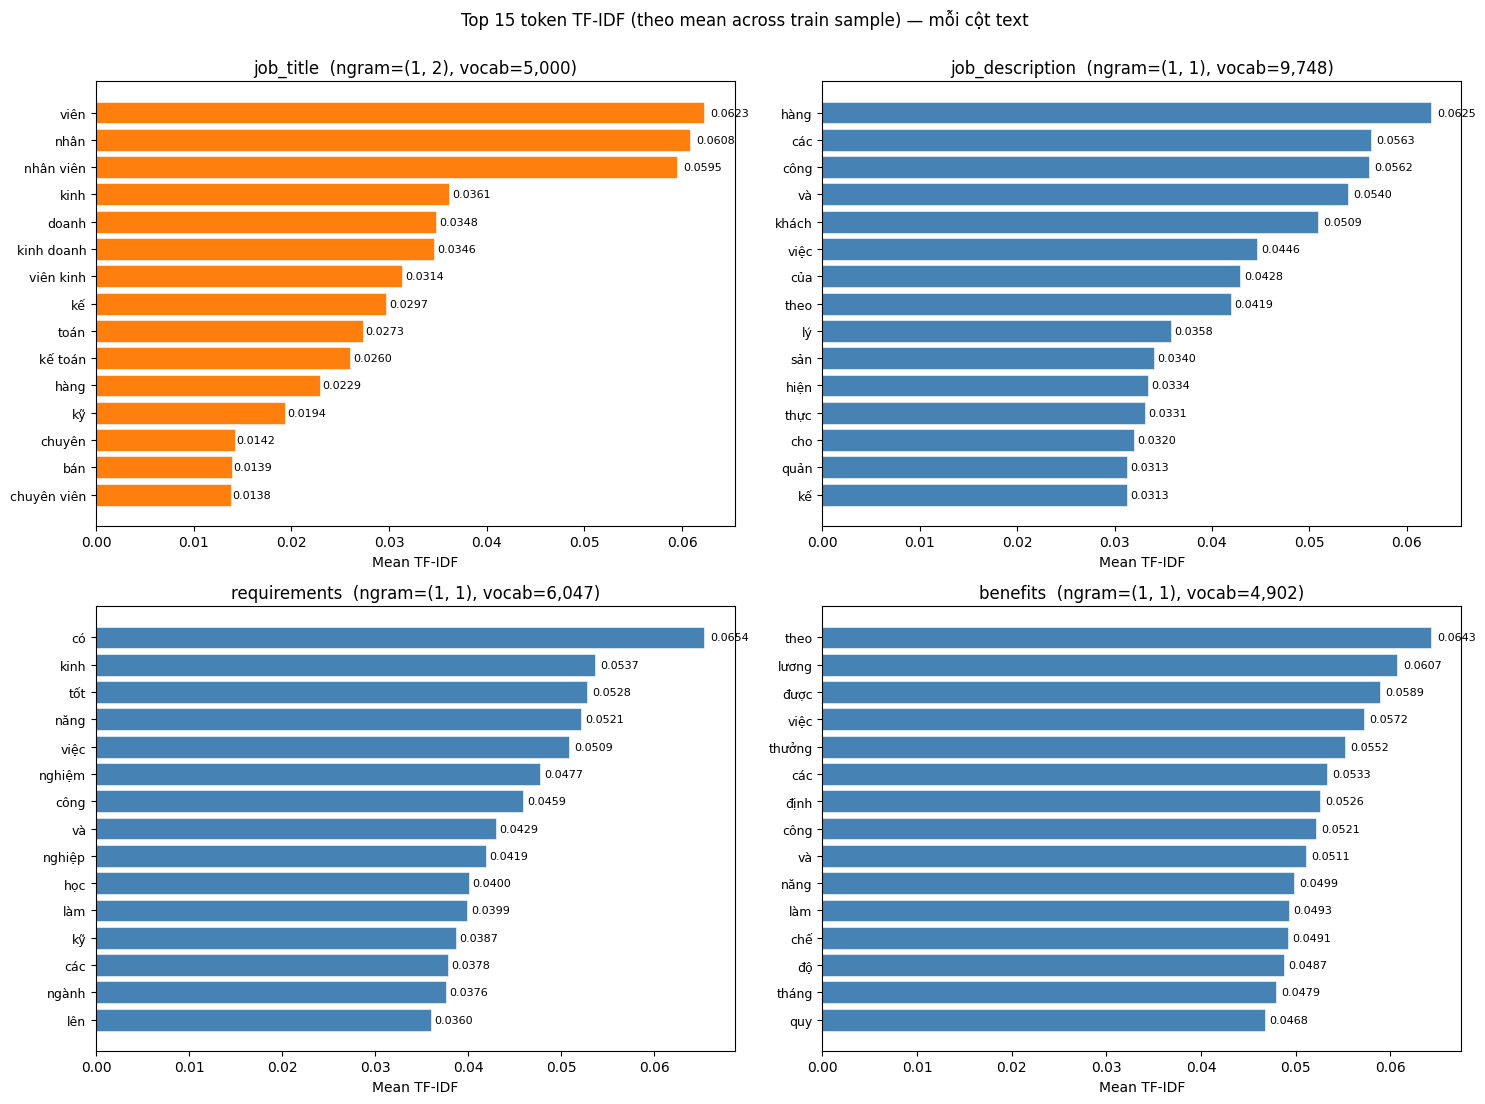

Đã lưu: D:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\figures\fe_tfidf_top_terms.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes_flat = axes.flat

for ax, (col, params), block in zip(axes_flat, TFIDF_COLS_PARAMS, text_train_blocks):
    vec = tfidf_models[col]
    vocab = vec.get_feature_names_out()
    # mean TF-IDF qua tất cả document (sum / nrow vì matrix sparse)
    mean_tfidf = np.asarray(block.mean(axis=0)).ravel()
    top_idx = np.argsort(mean_tfidf)[-15:]
    tokens = vocab[top_idx]
    values = mean_tfidf[top_idx]

    color = 'tab:orange' if col == 'job_title' else 'steelblue'
    ax.barh(np.arange(len(tokens)), values, color=color, edgecolor='white', linewidth=0.4)
    ax.set_yticks(np.arange(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=9)
    ax.set_xlabel('Mean TF-IDF')
    ax.set_title(f"{col}  (ngram={vec.ngram_range}, vocab={len(vec.vocabulary_):,})")
    for i, v in enumerate(values):
        ax.text(v * 1.01, i, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Top 15 token TF-IDF (theo mean across train sample) — mỗi cột text', y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fe_tfidf_top_terms.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIG_DIR / 'fe_tfidf_top_terms.png'}")

## 7. Hstack tất cả — sparse X trên train sample (kiểm shape + density)

Thứ tự nhóm cột: `numeric → one_hot → industries → tfidf_job_title → tfidf_job_description → tfidf_requirements → tfidf_benefits`.

Bước này chỉ tạo X sparse cho **sample 150k** để: (a) kiểm shape + density, (b) fit TruncatedSVD ở Section 8. Bước transform FULL data → save artifact chạy chunked ở Section 9.

In [11]:
X_num_train_sparse = sparse.csr_matrix(X_num_train_scaled, dtype=np.float32)

blocks_train = [X_num_train_sparse, X_cat_train, X_ind_train] + text_train_blocks

X_train_sample = sparse.hstack(blocks_train, format='csr', dtype=np.float32)

group_names = ['numeric', 'one_hot', 'industries'] + [f'tfidf_{c}' for c in TEXT_COLS]
sizes = [b.shape[1] for b in blocks_train]
ends = list(np.cumsum(sizes))
starts = [0] + ends[:-1]
groups = {name: [int(s), int(e)] for name, s, e in zip(group_names, starts, ends)}

density = X_train_sample.nnz / (X_train_sample.shape[0] * X_train_sample.shape[1]) * 100
print(f"X_train_sample: {X_train_sample.shape} | nnz = {X_train_sample.nnz:,} | density = {density:.4f}%")
print(f"\nColumn groups:")
for name, (s, e) in groups.items():
    print(f"  {name:25s}: [{s:>6}, {e:>6})  ({e-s:>5} cột)")

X_train_sample: (150000, 25899) | nnz = 31,756,459 | density = 0.8174%

Column groups:
  numeric                  : [     0,      6)  (    6 cột)
  one_hot                  : [     6,    151)  (  145 cột)
  industries               : [   151,    202)  (   51 cột)
  tfidf_job_title          : [   202,   5202)  ( 5000 cột)
  tfidf_job_description    : [  5202,  14950)  ( 9748 cột)
  tfidf_requirements       : [ 14950,  20997)  ( 6047 cột)
  tfidf_benefits           : [ 20997,  25899)  ( 4902 cột)


### Trực quan — thành phần 32k feature theo nhóm

2 góc nhìn: (1) **số cột** mỗi nhóm — TF-IDF text áp đảo (~32k/32.1k); (2) **đóng góp nnz** (non-zero entries) — vì TF-IDF sparse hơn nhiều so với numeric/OHE/multi-label (dense per row).

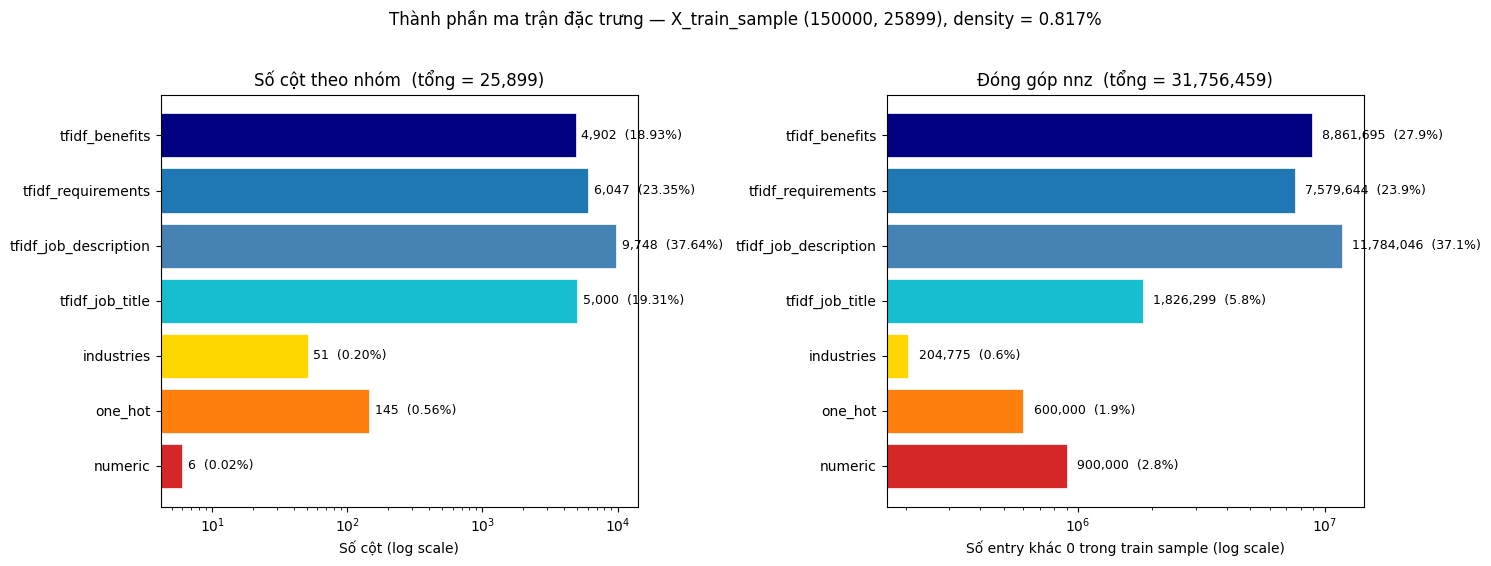

Đã lưu: D:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\figures\fe_group_breakdown.png


In [12]:
group_sizes = {name: e - s for name, (s, e) in groups.items()}
group_nnz = {name: int(X_train_sample[:, s:e].nnz) for name, (s, e) in groups.items()}

names = list(group_sizes.keys())
sizes_arr = np.array([group_sizes[n] for n in names])
nnz_arr = np.array([group_nnz[n] for n in names])

palette_g = {
    'numeric': 'tab:red',
    'one_hot': 'tab:orange',
    'industries': 'gold',
    'tfidf_job_title': 'tab:cyan',
    'tfidf_job_description': 'steelblue',
    'tfidf_requirements': 'tab:blue',
    'tfidf_benefits': 'navy',
}
colors_g = [palette_g.get(n, 'gray') for n in names]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
y_pos = np.arange(len(names))[::-1]

ax = axes[0]
ax.barh(y_pos, sizes_arr, color=colors_g, edgecolor='white', linewidth=0.5)
ax.set_xscale('log')
ax.set_yticks(y_pos)
ax.set_yticklabels(names)
ax.set_xlabel('Số cột (log scale)')
ax.set_title(f'Số cột theo nhóm  (tổng = {sizes_arr.sum():,})')
for i, s in enumerate(sizes_arr):
    pct = s / sizes_arr.sum() * 100
    ax.text(s * 1.1, y_pos[i], f'{s:,}  ({pct:.2f}%)', va='center', fontsize=9)
ax.invert_yaxis()

ax = axes[1]
ax.barh(y_pos, nnz_arr, color=colors_g, edgecolor='white', linewidth=0.5)
ax.set_xscale('log')
ax.set_yticks(y_pos)
ax.set_yticklabels(names)
ax.set_xlabel('Số entry khác 0 trong train sample (log scale)')
ax.set_title(f'Đóng góp nnz  (tổng = {nnz_arr.sum():,})')
for i, n in enumerate(nnz_arr):
    pct = n / nnz_arr.sum() * 100
    ax.text(n * 1.1, y_pos[i], f'{n:,}  ({pct:.1f}%)', va='center', fontsize=9)
ax.invert_yaxis()

plt.suptitle(f'Thành phần ma trận đặc trưng — X_train_sample {X_train_sample.shape}, density = {density:.3f}%', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fe_group_breakdown.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIG_DIR / 'fe_group_breakdown.png'}")

## 8. TruncatedSVD — giảm chiều 32k sparse → 100 dense

K-Means và silhouette dựa trên distance Euclidean — KHÔNG scale tốt với 32k chiều sparse (curse of dimensionality + tính distance trên 545k × 32k cực chậm).

`TruncatedSVD` (LSA / latent semantic analysis) giảm xuống dense ~100 chiều giữ phần lớn variance. Fit trên sample 150k, transform full ở Section 9.

In [13]:
print(f"Fitting TruncatedSVD(n_components={SVD_N_COMPONENTS}) trên X_train_sample {X_train_sample.shape}...")
svd = TruncatedSVD(n_components=SVD_N_COMPONENTS, random_state=RANDOM_STATE, algorithm='randomized')
X_train_svd_sample = svd.fit_transform(X_train_sample).astype(np.float32)

cum_var = np.cumsum(svd.explained_variance_ratio_)
print(f"\nExplained variance ratio:")
print(f"  total ({SVD_N_COMPONENTS} components): {cum_var[-1]*100:.2f}%")
for n in [10, 20, 50, 100]:
    if n <= len(cum_var):
        print(f"  first {n:>3} components       : {cum_var[n-1]*100:.2f}%")

print(f"\nX_train_svd_sample shape: {X_train_svd_sample.shape}, dtype={X_train_svd_sample.dtype}")
print(f"Memory dense (sample 150k × {SVD_N_COMPONENTS} × 4 bytes): "
      f"{X_train_svd_sample.nbytes / 1e6:.1f} MB")

Fitting TruncatedSVD(n_components=100) trên X_train_sample (150000, 25899)...



Explained variance ratio:
  total (100 components): 75.60%
  first  10 components       : 56.30%
  first  20 components       : 64.17%
  first  50 components       : 71.79%
  first 100 components       : 75.60%

X_train_svd_sample shape: (150000, 100), dtype=float32
Memory dense (sample 150k × 100 × 4 bytes): 60.0 MB


### Trực quan — cumulative explained variance

Đường cong cumulative variance giúp biện minh chọn `n_components`. Điểm "khuỷu" (elbow) cho biết bao nhiêu chiều đủ để giữ phần lớn cấu trúc. Mặc định `n_components=100` thường giữ 60-80% variance cho TF-IDF text data — cân bằng giữa thông tin và memory.

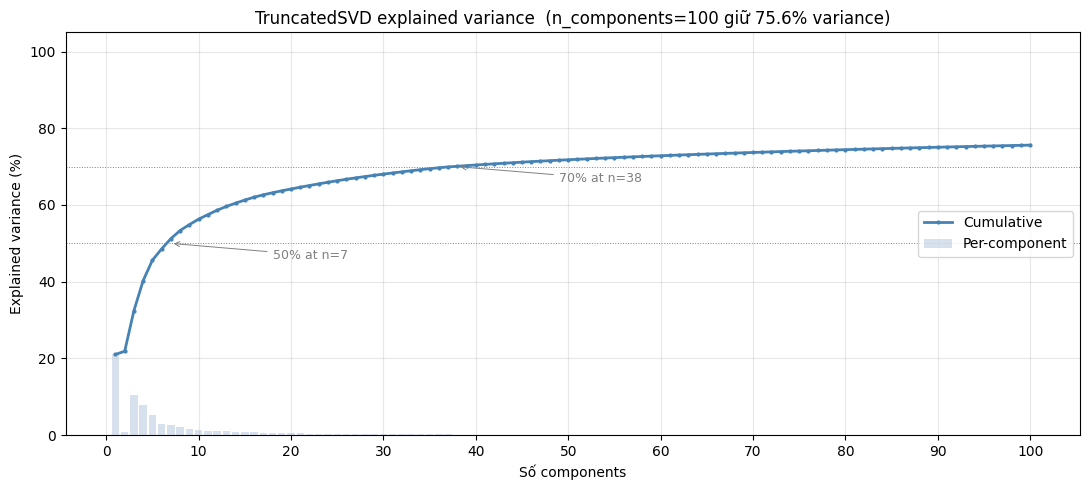

Đã lưu: D:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\figures\fe_svd_explained_variance.png


In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
xs = np.arange(1, len(cum_var) + 1)
ax.plot(xs, cum_var * 100, color='steelblue', lw=2, marker='.', markersize=4, label='Cumulative')
ax.bar(xs, svd.explained_variance_ratio_ * 100, color='lightsteelblue',
       alpha=0.5, width=0.8, label='Per-component')

# Annotate threshold points
for thr in [50, 70, 80]:
    idx = int(np.searchsorted(cum_var, thr / 100))
    if 0 <= idx < len(cum_var):
        ax.axhline(thr, color='gray', linestyle=':', lw=0.7)
        ax.annotate(f'{thr}% at n={idx+1}',
                    xy=(idx + 1, thr), xytext=(min(idx + 12, SVD_N_COMPONENTS - 5), thr - 4),
                    fontsize=9, color='gray',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.7))

ax.set_xlabel('Số components')
ax.set_ylabel('Explained variance (%)')
ax.set_title(f'TruncatedSVD explained variance  '
             f'(n_components={SVD_N_COMPONENTS} giữ {cum_var[-1]*100:.1f}% variance)')
ax.set_xticks(np.arange(0, SVD_N_COMPONENTS + 1, 10))
ax.set_ylim(0, max(105, cum_var[-1] * 100 + 5))
ax.grid(alpha=0.3)
ax.legend(loc='center right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fe_svd_explained_variance.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIG_DIR / 'fe_svd_explained_variance.png'}")

## 9. Apply chunked lên FULL data + lưu artifact

Đến đây toàn bộ transformer (imputer, scaler, OHE, MLB, TF-IDF, SVD) đã fit. Bước này:

1. **Transform test full** (load đã có sẵn trong memory).
2. **Transform train chunked** (50k row/batch → vstack sparse blocks).
3. SVD transform một lần trên ma trận đã vstack → dense.
4. Lưu cả 2 dạng: sparse `X_*.npz` (cho cluster profiling) + dense `X_*_svd.npy` (cho K-Means/silhouette).

In [15]:
def transform_df_sparse(df):
    """Áp toàn bộ transformer (đã fit) lên 1 DataFrame, trả về sparse CSR. KHÔNG áp SVD ở đây."""
    df = clean_df(df.copy())
    X_num = num_scaler.transform(num_imputer.transform(df[NUM_COLS])).astype(np.float32)
    X_num_sp = sparse.csr_matrix(X_num)
    X_cat = ohe.transform(df[CAT_COLS]).astype(np.float32)
    ind_lists = df['industries_list'].map(to_industry_list).tolist()
    X_ind = mlb.transform(ind_lists).astype(np.float32)
    X_texts = [tfidf_models[col].transform(df[col]).astype(np.float32) for col in TEXT_COLS]
    return sparse.hstack([X_num_sp, X_cat, X_ind] + X_texts, format='csr', dtype=np.float32)


# === Transform TEST (full, đã load sẵn) ===
print("=== Transform TEST (full) ===")
X_test = transform_df_sparse(test)
print(f"X_test sparse: {X_test.shape} ({X_test.nnz:,} nnz)")

# === Transform TRAIN chunked ===
print(f"\n=== Transform TRAIN chunked (size={CHUNK_SIZE:,}) ===")
sparse_chunks = []
n_processed = 0
for chunk in pd.read_csv(CLEAN / 'clean_data_train.csv', chunksize=CHUNK_SIZE):
    sparse_chunks.append(transform_df_sparse(chunk))
    n_processed += len(chunk)
    sys.stdout.write(f"\r  processed {n_processed:>9,}/{N_TRAIN_FULL:,} "
                     f"({n_processed*100/N_TRAIN_FULL:5.1f}%)")
    sys.stdout.flush()
print()

X_train = sparse.vstack(sparse_chunks, format='csr')
del sparse_chunks
print(f"\nX_train sparse: {X_train.shape} ({X_train.nnz:,} nnz, "
      f"density={X_train.nnz/X_train.shape[0]/X_train.shape[1]*100:.4f}%)")

# === SVD transform một lần ===
print("\nSVD transform full train + test...")
X_train_svd = svd.transform(X_train).astype(np.float32)
X_test_svd = svd.transform(X_test).astype(np.float32)
print(f"X_train_svd: {X_train_svd.shape} dense ({X_train_svd.nbytes/1e6:.1f} MB)")
print(f"X_test_svd : {X_test_svd.shape} dense ({X_test_svd.nbytes/1e6:.1f} MB)")

=== Transform TEST (full) ===


X_test sparse: (60606, 25899) (12,802,052 nnz)

=== Transform TRAIN chunked (size=50,000) ===


  processed    50,000/545,480 (  9.2%)

  processed   100,000/545,480 ( 18.3%)

  processed   150,000/545,480 ( 27.5%)

...

  processed   500,000/545,480 ( 91.7%)

  processed   545,480/545,480 (100.0%)


X_train sparse: (545480, 25899) (115,436,305 nnz, density=0.8171%)



SVD transform full train + test...


X_train_svd: (545480, 100) dense (218.2 MB)
X_test_svd : (60606, 100) dense (24.2 MB)


In [16]:
# === Save sparse X + dense SVD X ===
sparse.save_npz(FEATURES / 'X_train.npz', X_train)
sparse.save_npz(FEATURES / 'X_test.npz', X_test)
np.save(FEATURES / 'X_train_svd.npy', X_train_svd)
np.save(FEATURES / 'X_test_svd.npy', X_test_svd)

# === Save transformers + meta + feature_names ===
joblib.dump(
    {
        'num_imputer': num_imputer,
        'num_scaler': num_scaler,
        'ohe': ohe,
        'mlb': mlb,
        'tfidf': tfidf_models,
        'svd': svd,
    },
    FEATURES / 'transformers.joblib',
    compress=3,
)

feature_names = (
    list(NUM_COLS)
    + list(ohe.get_feature_names_out(CAT_COLS))
    + [f"ind__{c}" for c in mlb.classes_]
)
for col in TEXT_COLS:
    vocab = tfidf_models[col].get_feature_names_out()
    feature_names += [f"tfidf_{col}__{tok}" for tok in vocab]
assert len(feature_names) == X_train.shape[1]
(FEATURES / 'feature_names.txt').write_text('\n'.join(feature_names), encoding='utf-8')

meta = {
    'n_train': int(X_train.shape[0]),
    'n_test': int(X_test.shape[0]),
    'n_features_sparse': int(X_train.shape[1]),
    'n_features_svd': int(X_train_svd.shape[1]),
    'svd_explained_variance_ratio_total': float(svd.explained_variance_ratio_.sum()),
    'svd_explained_variance_ratio_per_comp': svd.explained_variance_ratio_.tolist(),
    'groups': groups,
    'num_cols': NUM_COLS,
    'cat_cols': CAT_COLS,
    'text_cols': TEXT_COLS,
    'tfidf_params': {
        'long': {**TFIDF_PARAMS_LONG, 'ngram_range': list(TFIDF_PARAMS_LONG['ngram_range'])},
        'title': {**TFIDF_PARAMS_TITLE, 'ngram_range': list(TFIDF_PARAMS_TITLE['ngram_range'])},
    },
    'sample_size_used_for_fit': SAMPLE_SIZE,
    'chunk_size': CHUNK_SIZE,
}
(FEATURES / 'meta.json').write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding='utf-8')

print('Đã lưu:')
for fn in ['X_train.npz', 'X_test.npz', 'X_train_svd.npy', 'X_test_svd.npy',
           'transformers.joblib', 'meta.json', 'feature_names.txt']:
    p = FEATURES / fn
    print(f'  {fn:25s} {p.stat().st_size / 1e6:>7.2f} MB')

Đã lưu:
  X_train.npz                507.82 MB
  X_test.npz                  59.42 MB
  X_train_svd.npy            218.19 MB
  X_test_svd.npy              24.24 MB
  transformers.joblib         10.09 MB
  meta.json                    0.00 MB
  feature_names.txt            0.72 MB


## 10. Sanity check — reload + cluster preview

Load lại artifact từ disk, kiểm shape. Vì không có y, thay vì correlation test, xem khoảng cách giữa centroid của vài nhóm ngành rõ ràng trong SVD space — nếu các nhóm tách được thì sẵn sàng cho K-Means.

In [17]:
X_train_loaded = sparse.load_npz(FEATURES / 'X_train.npz')
X_train_svd_loaded = np.load(FEATURES / 'X_train_svd.npy')
meta_loaded = json.loads((FEATURES / 'meta.json').read_text(encoding='utf-8'))

assert X_train_loaded.shape == X_train.shape
assert X_train_svd_loaded.shape == X_train_svd.shape
print(f"Reload OK:")
print(f"  X_train sparse: {X_train_loaded.shape} (nnz={X_train_loaded.nnz:,})")
print(f"  X_train svd   : {X_train_svd_loaded.shape}")
print(f"\nSVD giữ {meta_loaded['svd_explained_variance_ratio_total']*100:.2f}% variance "
      f"trên {meta_loaded['n_features_svd']} chiều dense.")

# Cluster preview trên sample 150k: centroid 5 ngành lớn nhất trong SVD space
print("\n--- Cluster preview: centroid 5 ngành lớn nhất (train sample) trong SVD space ---")
top5_inds = ['Bán hàng - Kinh doanh', 'Chăm sóc khách hàng', 'IT phần mềm',
             'Kế toán', 'Marketing']

ind_to_rows = {ind: [] for ind in top5_inds}
for i, lst in enumerate(train_inds):
    for ind in lst:
        if ind in ind_to_rows:
            ind_to_rows[ind].append(i)

centroids = {ind: X_train_svd_sample[rows].mean(axis=0)
             for ind, rows in ind_to_rows.items() if rows}

names = list(centroids.keys())
if len(names) >= 2:
    print(f"\nKhoảng cách Euclidean giữa centroid 5 ngành (trong SVD-100 space):")
    print(f"{'':32s}" + ''.join(f'{n[:13]:>14s}' for n in names))
    for n1 in names:
        row = f"{n1[:32]:32s}"
        for n2 in names:
            d = np.linalg.norm(centroids[n1] - centroids[n2])
            row += f'{d:>14.4f}'
        print(row)
    print(f"\nn samples mỗi ngành: " +
          ", ".join(f"{n}={len(ind_to_rows[n]):,}" for n in names))
    print("→ Khoảng cách > 0 rõ rệt = SVD đã tách signal ngành. Sẵn sàng cho K-Means ở stage 4.")

Reload OK:
  X_train sparse: (545480, 25899) (nnz=115,436,305)
  X_train svd   : (545480, 100)

SVD giữ 75.60% variance trên 100 chiều dense.

--- Cluster preview: centroid 5 ngành lớn nhất (train sample) trong SVD space ---

Khoảng cách Euclidean giữa centroid 5 ngành (trong SVD-100 space):
                                 Bán hàng - Ki Chăm sóc khác   IT phần mềm       Kế toán     Marketing
Bán hàng - Kinh doanh                   0.0000        1.4936        4.9496        2.1126        1.5909
Chăm sóc khách hàng                     1.4936        0.0000        4.7720        2.1275        1.6958
IT phần mềm                             4.9496        4.7720        0.0000        4.9623        4.8792
Kế toán                                 2.1126        2.1275        4.9623        0.0000        1.9933
Marketing                               1.5909        1.6958        4.8792        1.9933        0.0000

n samples mỗi ngành: Bán hàng - Kinh doanh=15,264, Chăm sóc khách hàng=18,694, IT phần m

## 11. Bước tiếp theo

Sang [04_Modeling.ipynb](./04_Modeling.ipynb):

1. `np.load('X_train_svd.npy')` (dense, 100 chiều) + `sparse.load_npz('X_train.npz')` (sparse, ~32k chiều, cho profiling) + `joblib.load('transformers.joblib')`.
2. **Clustering trên SVD-reduced X:**
   - **MiniBatchKMeans** loop k ∈ [3, 20] → vẽ elbow (inertia) + silhouette curve → chốt k tối ưu.
   - So sánh thêm **GaussianMixture** (BIC/AIC) hoặc **HDBSCAN** (không cần định k).
3. **Mô tả cluster**: với mỗi cụm k, in:
   - Top-10 TF-IDF tokens: lấy mean của X sparse trong các dòng thuộc cluster k → top tokens trong feature_names.
   - Top-5 industries / province / education / job_position.
   - Mean salary_mid, mean years_exp, year distribution.
4. **Gán nhãn cụm** thủ công sau khi xem profile (vd. *"IT mid-level HCM"*, *"Manufacturing Bắc Bộ junior"*).
5. **Visualization**: t-SNE/UMAP 2D từ SVD-100 → scatter colored by cluster.
6. **Demo trên test** (yêu cầu template báo cáo): random 10 mẫu test → predict cluster → in cluster_id + nhãn + các trường chính (`job_title`, `salary`, `province`, `industries_list`, `years_exp`, `education_level`).